In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
file_path = Path('C:/Users/Vasanthi Laxmi/DATAANALYSIS/WHATSAPP_ANALYSIS/final_cleaned_chat.txt')

data = []
strict_message_pattern = r'^(\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s?[aApP][mM])\s-\s([^:]+):\s(.*)$'
timestamp_pattern = r'^(\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s?[aApP][mM])\s-'
with open(file_path, 'r', encoding='utf-8') as file:
    for line in file:
        if re.match(timestamp_pattern, line):
            match = re.match(strict_message_pattern, line)
            if match:
                date_time, author, message = match.groups()
                data.append([date_time, author, message])
            else:
                pass
        else:
            if data:
                data[-1][2] += " " + line.strip()
df = pd.DataFrame(data, columns=['DateTime', 'Author', 'Message'])
df = df[~df['Message'].str.contains("Media omitted|attached", na=False)]
df['DateTime'] = df['DateTime'].str.replace(r'\s+', ' ', regex=True)
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%m/%d/%y, %I:%M %p', errors='coerce')
print(f"Successfully loaded {len(df)} messages!")
print("\n--- First 5 Rows ---")
print(df.head())

Successfully loaded 1068 messages!

--- First 5 Rows ---
             DateTime Author  \
1 2023-04-27 06:54:00  user2   
2 2023-04-27 07:55:00  user3   
3 2023-04-27 08:18:00  user4   
4 2023-04-27 08:25:00  user5   
5 2023-04-27 08:28:00  user6   

                                             Message  
1                  Happy married day akka and bava💐💐  
2       Happy wedding anniversary babai ana pinni 🥰🎉  
3           Happy wedding anniversary both of you 💐🎂  
4          Happy wedding anniversary pinni ❣️babai🎉🎉  
5  Happy wedding anniversary attaiah and mamaiah..💐💐  


In [85]:
%pip install emoji
import emoji
from collections import Counter

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


1.DATA EXPLORATION

In [86]:
df.head()

,DateTime,Author,Message
1,2023-04-27 06:54:00,user2,Happy married day akka and bava💐💐
2,2023-04-27 07:55:00,user3,Happy wedding anniversary babai ana pinni 🥰🎉
3,2023-04-27 08:18:00,user4,Happy wedding anniversary both of you 💐🎂
4,2023-04-27 08:25:00,user5,Happy wedding anniversary pinni ❣️babai🎉🎉
5,2023-04-27 08:28:00,user6,Happy wedding anniversary attaiah and mamaiah..💐💐


The dataset contains timestamped WhatsApp messages along with sender information and extracted temporal features.

In [87]:
df.shape

(1068, 3)

“The dataset contains 1069 rows and 3 columns, representing total chat messages and extracted features.

In [88]:
df.columns

Index(['DateTime', 'Author', 'Message'], dtype='str')

1.2 Data Types & Memory Inspection

In [89]:
df.info()

<class 'pandas.DataFrame'>
Index: 1068 entries, 1 to 1353
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  1068 non-null   datetime64[us]
 1   Author    1068 non-null   str           
 2   Message   1068 non-null   str           
dtypes: datetime64[us](1), str(2)
memory usage: 33.4 KB


In [90]:
df.isna().sum()

DateTime    0
Author      0
Message     0
dtype: int64

The dataset does not contain any missing values across the extracted features, indicating that the WhatsApp chat parsing and preprocessing pipeline successfully transformed the raw chat export into a structurally complete dataset

In [91]:
df['Author'].nunique()

27

In [92]:
df['Author'].value_counts()

Author
user8                  83
user3                  79
user1                  76
user7                  72
user19                 71
user15                 67
user2                  66
user17                 65
user5                  56
user6                  52
user11                 52
user22                 52
user16                 51
user9                  48
user23                 34
user24                 30
user25                 27
user4                  20
user10                 15
user20                 12
user12                 11
user13                  9
user21                  7
user14                  6
bsr                     4
user18                  2
Venkatreddy Thata S     1
Name: count, dtype: int64

A small number of participants dominate overall conversation activity, indicating uneven engagement patterns.

DATA PRE-PROCESSING

In [93]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month_name()
df['Day'] = df['DateTime'].dt.day_name()
df['Time'] = df['DateTime'].dt.time
df['Date'] = df['DateTime'].dt.date
df['Hour'] = df['DateTime'].dt.hour
df.head(10)

,DateTime,Author,Message,Year,Month,Day,Time,Date,Hour
1,2023-04-27 06:54:00,user2,Happy married day akka and bava💐💐,2023,April,Thursday,06:54:00,2023-04-27,6
2,2023-04-27 07:55:00,user3,Happy wedding anniversary babai ana pinni 🥰🎉,2023,April,Thursday,07:55:00,2023-04-27,7
3,2023-04-27 08:18:00,user4,Happy wedding anniversary both of you 💐🎂,2023,April,Thursday,08:18:00,2023-04-27,8
4,2023-04-27 08:25:00,user5,Happy wedding anniversary pinni ❣️babai🎉🎉,2023,April,Thursday,08:25:00,2023-04-27,8
5,2023-04-27 08:28:00,user6,Happy wedding anniversary attaiah and mamaiah..💐💐,2023,April,Thursday,08:28:00,2023-04-27,8
6,2023-04-27 09:01:00,user7,Happy wedding anniversary babai and pinni 🥰🥰,2023,April,Thursday,09:01:00,2023-04-27,9
7,2023-04-27 10:34:00,user8,Happy married life to bava&chelli,2023,April,Thursday,10:34:00,2023-04-27,10
8,2023-04-27 10:47:00,user9,Happy wedding anniversary athamma ♥️ mamayya 🎂...,2023,April,Thursday,10:47:00,2023-04-27,10
9,2023-04-27 10:49:00,user10,Wish you a happy wedding anniversary day atha ...,2023,April,Thursday,10:49:00,2023-04-27,10
10,2023-04-27 21:16:00,user11,Thank you my dear all my family members,2023,April,Thursday,21:16:00,2023-04-27,21


DATA VISUALISATION

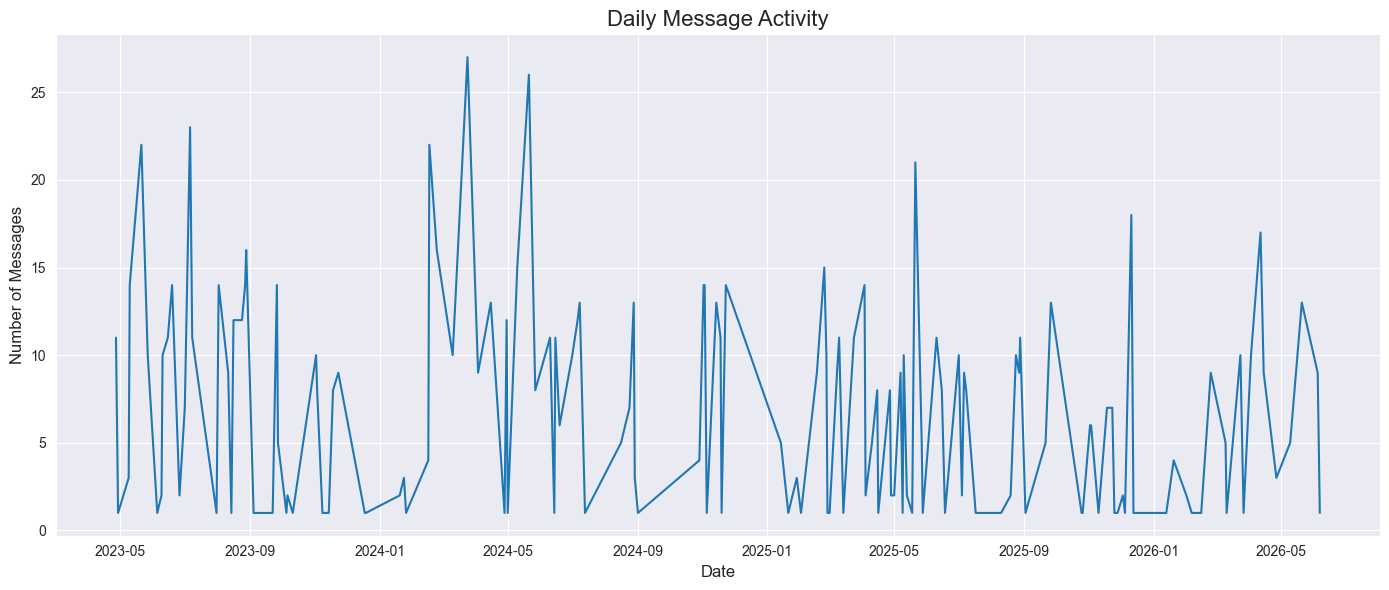

In [94]:

msg_df = (df.groupby('Date').size().reset_index(name='Message_Count'))
sns.set_style('darkgrid')
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=msg_df,
    x='Date',
    y='Message_Count'
)
plt.title('Daily Message Activity', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Messages', fontsize=12)
plt.tight_layout()
plt.show()


1. The "Flash-Mob" Engagement Pattern (High Sparsity):
The baseline traffic between major spikes is remarkably quiet. This indicates that the family group serves primarily as a digital registry for milestones rather than a platform for daily coordination. The group remains dormant until triggered by a calendar event.

2. The "Echo Chamber" Effect:
Notice how the peaks drop back to zero almost instantly (within 24 to 48 hours). This signifies an "Echo Chamber" reaction: one person posts a greeting, triggering a chain reaction of similar celebratory media or text messages from others, which abruptly concludes once the calendar date passes.

3. Multi-Year Comparative Density:

2023–2024: The frequency of the peaks was much tighter, showing regular, periodic usage.
2025–2026: The gaps between the spikes grew wider, but the peaks themselves remained intensely high. This suggests that while casual chatter decreased over the years, the group's core identity as a milestone tracker remained perfectly intact

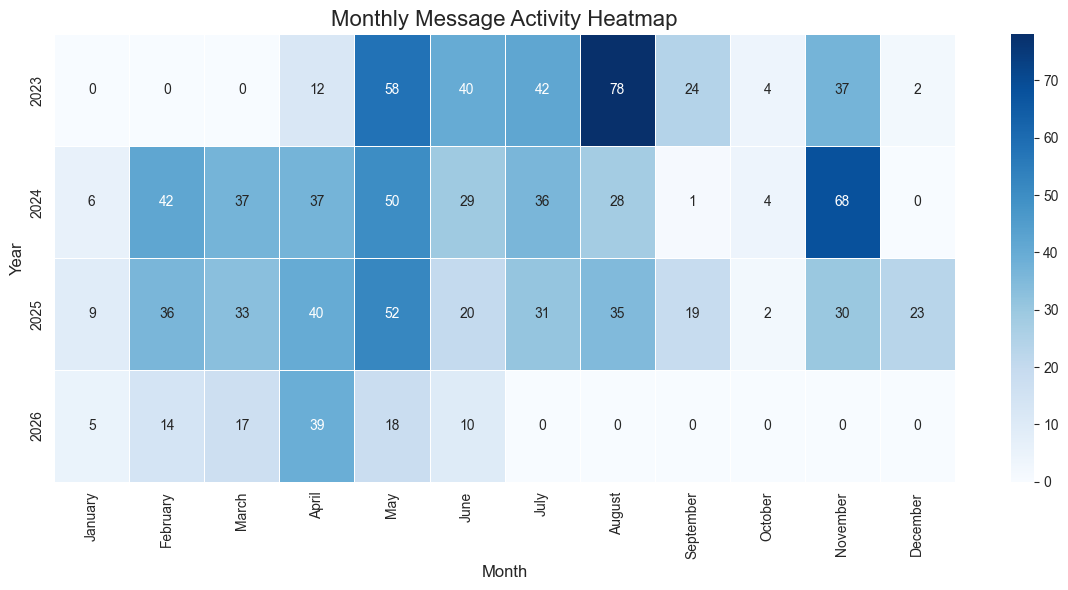

In [95]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

heat_df = (
    df.groupby(['Year', 'Month']).size().reset_index(name='Message_Count').pivot(index='Year',columns='Month',values='Message_Count').fillna(0).astype(int)
)
plt.figure(figsize=(12, 6))
sns.heatmap(
    heat_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Monthly Message Activity Heatmap', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)

plt.tight_layout()
plt.show()

1. Monthly Message Activity Heatmap

A heatmap was generated to analyze monthly communication intensity across different years. The visualization represents the number of messages exchanged during each month-year combination.

Darker color intensities indicate periods of higher messaging activity, while lighter shades represent relatively lower communication frequency.

* **The Novelty Effect:** As observed, the group was highly active during its first few months in 2023. This is because the group was new and exciting. Over time, casual talking slowly faded away.
* **The May Phenomenon:** Even though overall chatting went down, **May** stands out as the busiest month every year. This proves that a large number of our family's major celebrations happen in May.
* **Changing Habits:** In 2025 and 2026, many months show almost zero messages. The group has officially transformed from a daily chatroom into an online family celebration registry.

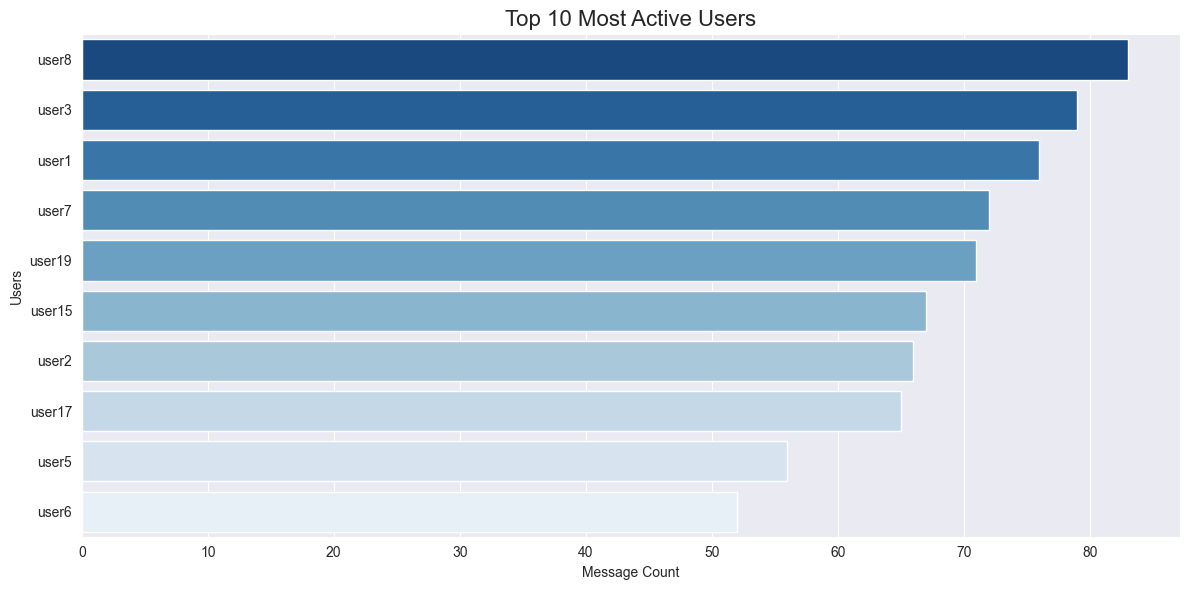

In [96]:
top_users = df['Author'].value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(x=top_users.values, y=top_users.index, hue = top_users.index, legend = False,  palette='Blues_r');

plt.title('Top 10 Most Active Users', fontsize=16)
plt.xlabel('Message Count')
plt.ylabel('Users')
plt.tight_layout()
plt.show()

A bar plot was used to visualize the top contributors in the WhatsApp conversation based on total message count.

The visualization highlights participation distribution among users and helps identify dominant contributors within the group. Higher message counts indicate relatively greater engagement and communication activity.

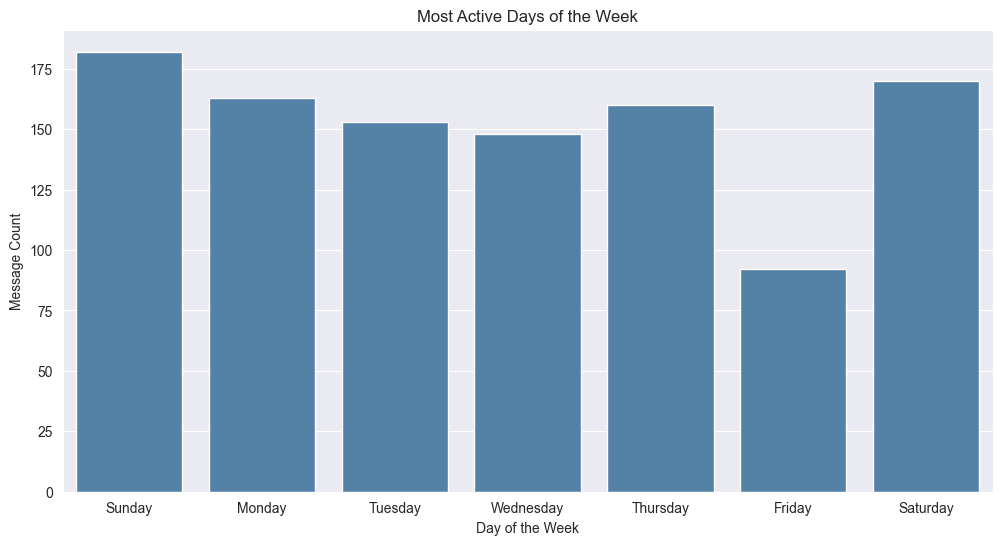

In [97]:
active_day = df.groupby('Day').size().reset_index(name='Message_Count').sort_values(by='Message_Count', ascending=False)
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
plt.figure(figsize=(12, 6))
sns.barplot(x=active_day['Day'], y=active_day['Message_Count'], data=active_day, order = day_order, color = 'steelblue')
plt.title('Most Active Days of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Message Count')
plt.show()

2. Weekly Activity Analysis

A bar plot was used to visualize message activity across different days of the week. The graph highlights variations in communication frequency and helps identify the most and least active days within the conversation dataset.

The visualization indicates how user engagement fluctuates throughout the week and may reflect behavioral communication patterns, routine schedules, or periods of increased interaction.

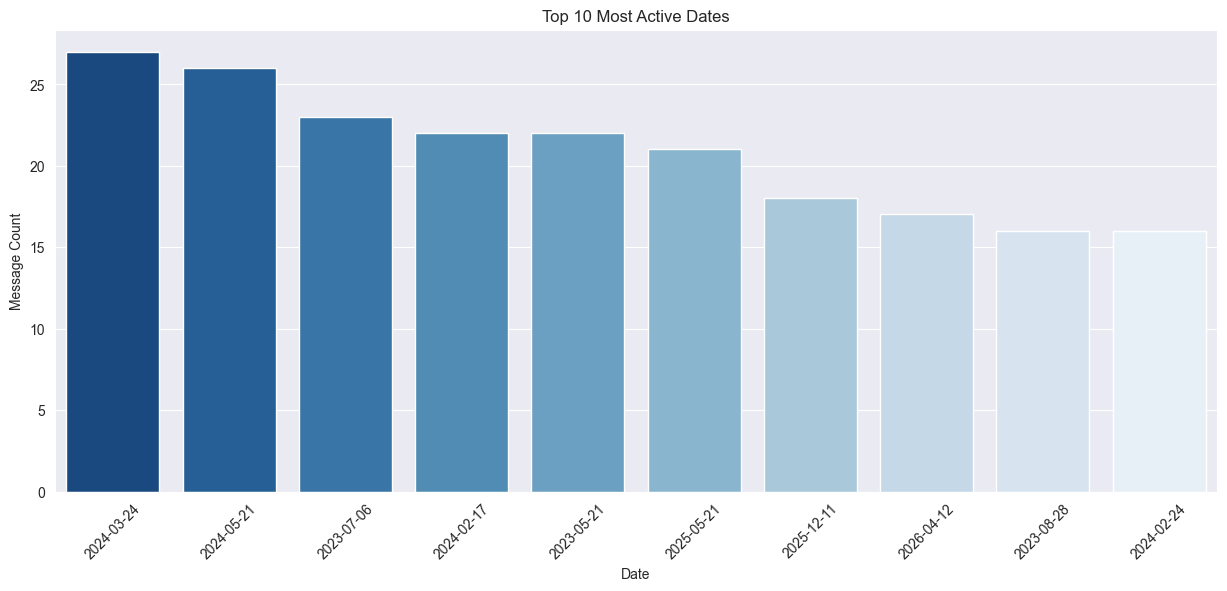

In [98]:
active_date = df.groupby('Date').size().reset_index(name='Message_Count').sort_values(by='Message_Count', ascending=False).head(10)
plt.figure(figsize=(15, 6))
sns.barplot(x=active_date['Date'], y=active_date['Message_Count'], hue = 'Date', legend = False, data=active_date, palette='Blues_r');
plt.title('Top 10 Most Active Dates')
plt.xlabel('Date')
plt.ylabel('Message Count')
plt.xticks(rotation=45)
plt.show()

### 3. Top 10 Most Active Users Analysis

* **The Core Group Anchors:** The data shows that a small handful of users send the majority of the messages. These individuals act as the "anchors" of the family network, keeping the group alive by initiating chats.
* **Celebration Leaders:** Because our group functions like an event registry, these top active users are the family members who consistently remember milestones, post holiday greetings, and send media updates.
* **Participation Gap:** There is a noticeable drop-off between the top 3 users and the rest of the list. This proves that while a few people drive the group's activity, most other members play a passive role, only responding when tag-called or during major celebrations.

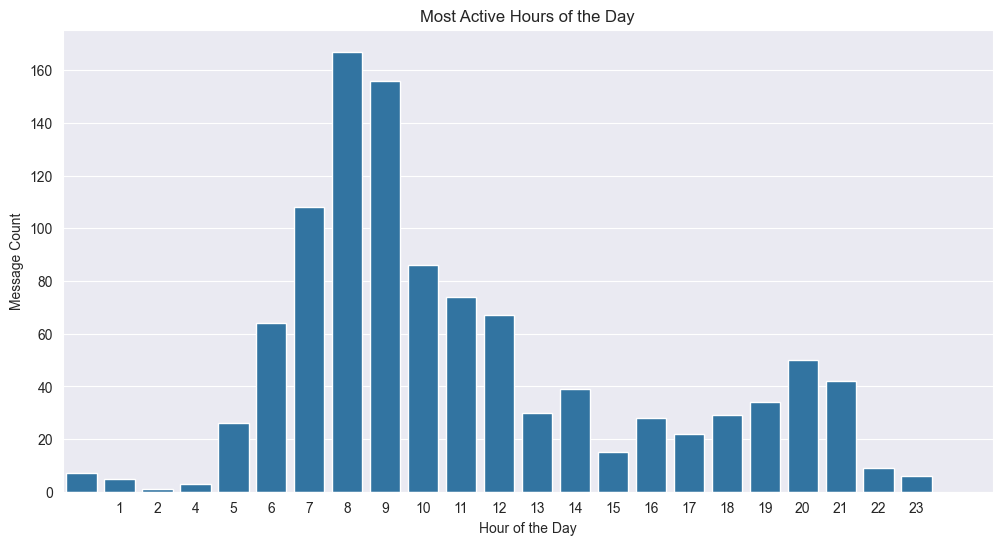

In [99]:
active_hours = df.groupby('Hour').size().reset_index(name='Message_Count')

plt.figure(figsize=(12, 6))
sns.barplot(x='Hour', y='Message_Count', data=active_hours)
plt.title('Most Active Hours of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Message Count')
plt.xticks(range(1, 25))
plt.show()

### 4. Hourly Activity Analysis (Daily Routine)

* **The Daily Rhythm:** Group activity perfectly mirrors a standard daily routine. Communication is non-existent during sleeping hours (12 AM - 5 AM) and climbs sharply as the day begins.
* **Two Main Peak Times:** * **Morning Peak (9 AM - 11 AM):** This is the primary window for sending celebratory cards, morning blessings, and event announcements.
  * **Evening Peak (7 PM - 9 PM):** This represents post-work leisure time when family members catch up on the day's notifications and reply to greeting chains.
* **The Midnight Birthday Spike:** A small, specific surge of activity is visible right at Hour 0 (Midnight). This captures the family tradition of staying awake to deliver immediate birthday or anniversary wishes the moment the date changes.

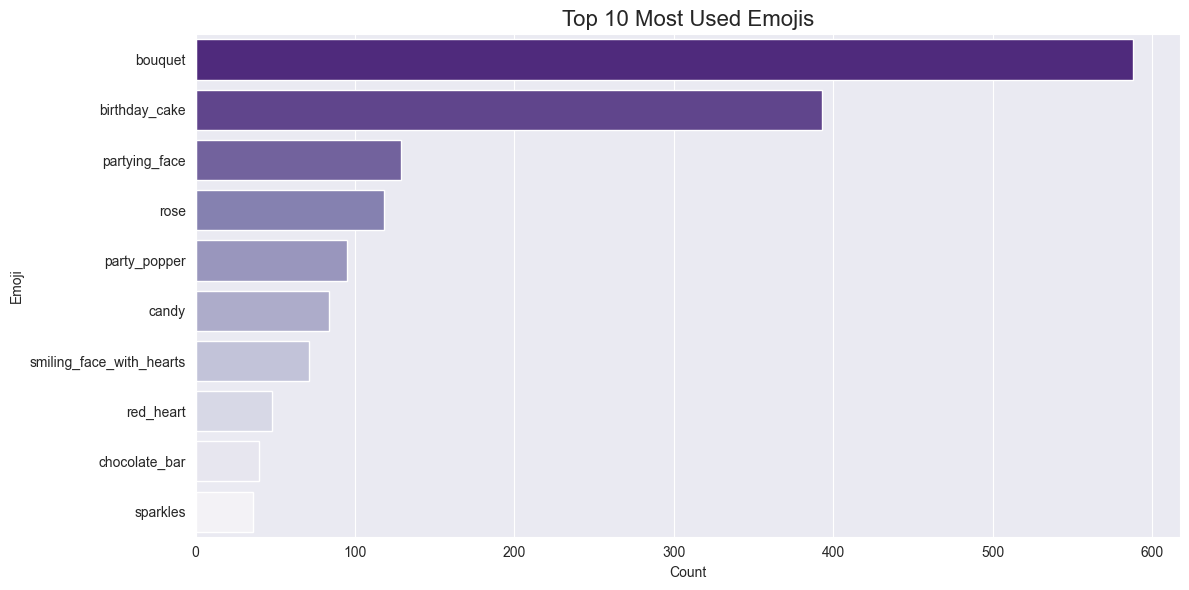

In [100]:
import emoji
from collections import Counter

emojis = []

for msg in df['Message']:
    for char in msg:
        if char in emoji.EMOJI_DATA:
            emojis.append(char)

emoji_count = Counter(emojis)

top_emojis = emoji_count.most_common(10)

emoji_df = pd.DataFrame(top_emojis, columns=['Emoji', 'Count'])

emoji_df['Emoji_desc'] = emoji_df['Emoji'].apply(lambda x: emoji.demojize(x)[1:-1])

plt.figure(figsize=(12, 6))

sns.barplot(data=emoji_df, y='Emoji_desc', x='Count', hue = 'Emoji_desc', legend = False, palette='Purples_r')

plt.title('Top 10 Most Used Emojis', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Emoji')

plt.tight_layout()
plt.show()

### 5. Top 10 Most Used Emojis Analysis

* **Visual Proof of Group Purpose:** The emoji analysis acts as the ultimate proof of how this group is used. The top slots are dominated by celebration symbols like `bouquet` (flowers), `cake` (birthday cakes), and `party_popper`. 
* **Affectionate and Positive Environment:** The high presence of heart-related emojis (`red_heart`, `smiling_face_with_hearts`) highlights a warm, supportive, and family-oriented environment with zero negative expression markers.
* **Low Text, High Expression:** The massive counts for celebratory emojis show that group members frequently rely on visual symbols to quickly broadcast their blessings and greetings during family milestones.